In [1]:
import os
# Switch to parent directory
os.chdir("..")
root = os.getcwd()

In [2]:
import sys
sys.path.insert(0, os.path.join(root, "src"))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spo.models.gbm import calibrate_gbm
from spo.models.simulate import simulated_moments, simulate_gbm_paths
from spo.optim import min_var_portfolio, max_sharpe_portfolio, estimate_covariance
from spo.backtest import backtest, summary

log_ret = pd.read_parquet(root + "/data/processed/sp500_log_returns.parquet")

# Calibrate on the most recent 2 years
calibration_window = log_ret.iloc[-504:]
params = calibrate_gbm(calibration_window)
annual = params.annualize(252)

print("Calibrated annualized parameters:")
pd.DataFrame({
    "Ann. Drift μ": annual.mu,
    "Ann. Vol σ": annual.sigma,
}).sort_values("Ann. Vol σ", ascending=False).head(10).style.format("{:.2%}")

Calibrated annualized parameters:


,Ann. Drift μ,Ann. Vol σ
SMCI,24.02%,97.04%
SATS,129.66%,76.76%
COHR,88.17%,63.61%
TSLA,57.55%,60.71%
GL,26.40%,60.39%
ALB,26.11%,57.60%
INTC,2.80%,56.33%
MU,75.90%,55.66%
FSLR,43.84%,55.02%
MPWR,34.44%,54.37%


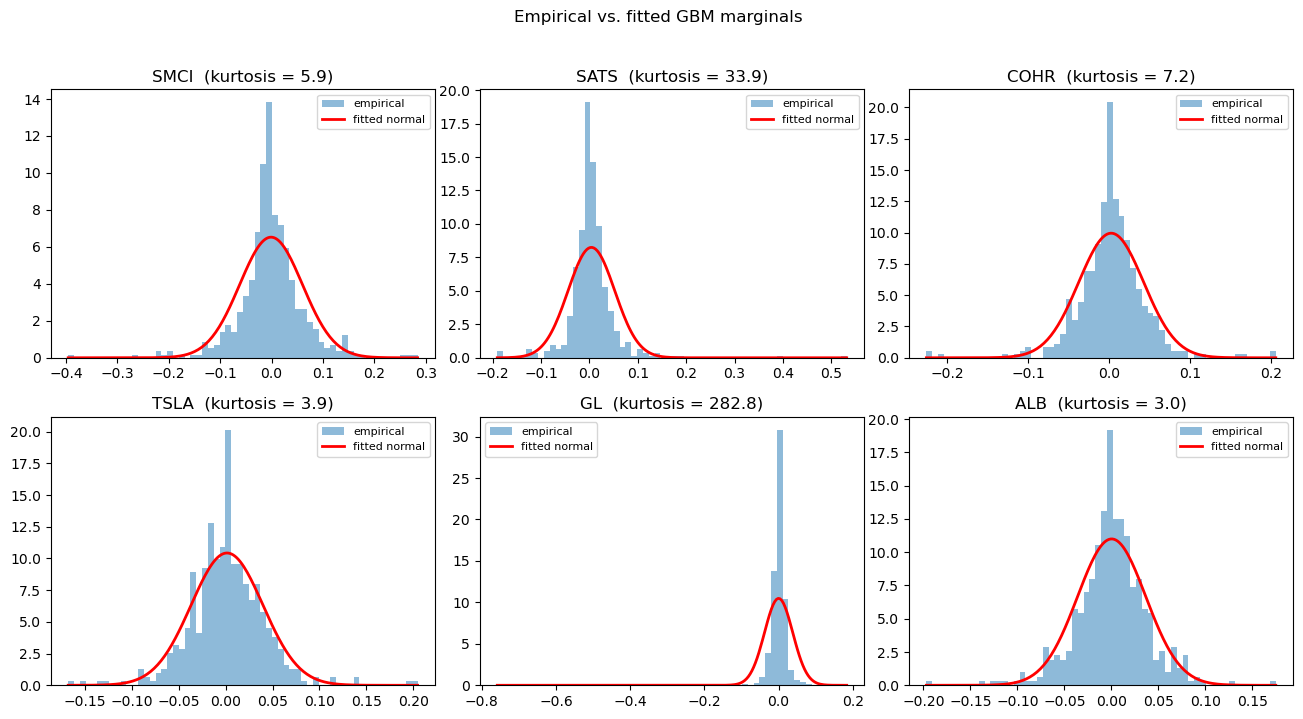

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
biggest = annual.sigma.nlargest(6).index
for ax, ticker in zip(axes.flat, biggest):
    r = calibration_window[ticker]
    ax.hist(r, bins=60, density=True, alpha=0.5, label="empirical")
    x = np.linspace(r.min(), r.max(), 200)
    pdf = (1 / (np.sqrt(2 * np.pi) * params.sigma[ticker])) * np.exp(
        -0.5 * ((x - (params.mu[ticker] - 0.5 * params.sigma[ticker] ** 2))
                / params.sigma[ticker]) ** 2
    )
    ax.plot(x, pdf, "r-", lw=2, label="fitted normal")
    ax.set_title(f"{ticker}  (kurtosis = {r.kurt():.1f})")
    ax.legend(fontsize=8)
plt.suptitle("Empirical vs. fitted GBM marginals", y=1.02)
plt.tight_layout(); plt.show()

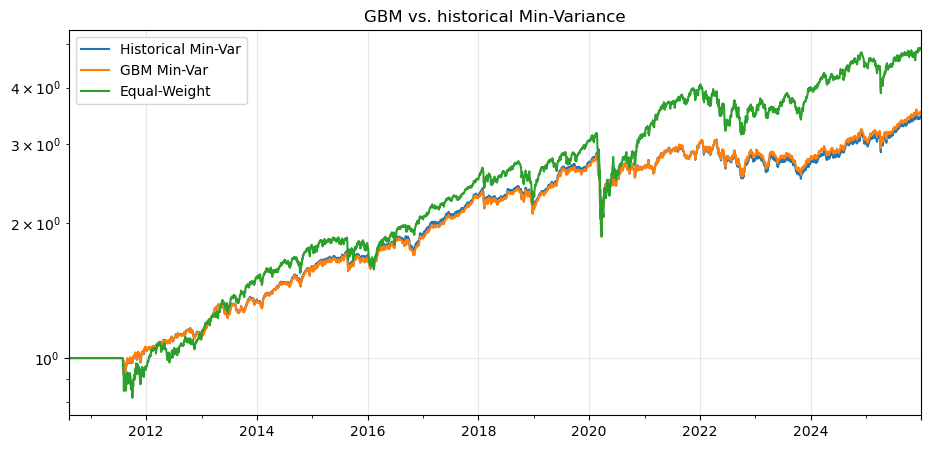

,Historical Min-Var,GBM Min-Var,Equal-Weight
Ann. Returns,0.080753,0.082310,0.104653
Ann. Vol,0.119246,0.118895,0.169727
Sharpe,0.711404,0.725240,0.671986
Sortino,0.780354,0.801461,0.759316
Max DD,-0.350367,-0.345465,-0.410271
Calmar,0.230481,0.238260,0.255083


In [ ]:
def gbm_min_var_strategy(lookback: pd.DataFrame) -> pd.Series:
    """Calibrate GBM on lookback, simulate, optimize on simulated covariance."""
    p = calibrate_gbm(lookback)

    # 1‑month horizon simulation
    sim = simulate_gbm_paths(
        p, n_paths=5000, n_steps=21, seed=0
    )

    # Extract simulated covariance
    _, cov_sim = simulated_moments(sim, p.tickers)

    # Directly pass covariance to optimizer
    return min_var_portfolio(
        returns=None,
        cov=cov_sim,
        long_only=True
    )

strategies = {
    "Historical Min-Var": lambda r: min_var_portfolio(r, "ledoit_wolf"),
    "GBM Min-Var": gbm_min_var_strategy,
    "Equal-Weight": lambda r: pd.Series(1 / r.shape[1], index=r.columns),
}

results = {
    name: backtest(log_ret, fn, rebalance_freq="BME",
                                lookback=504, cost=10.0)
    for name, fn in strategies.items()
}

fig, ax = plt.subplots(figsize=(11, 5))
for name, res in results.items():
    (1 + res["net_returns"]).cumprod().plot(ax=ax, label=name)
ax.set_yscale("log"); ax.set_title("GBM vs. historical Min-Variance")
ax.legend(); ax.grid(alpha=0.3); plt.show()

pd.concat({name: summary(res["net_returns"]) for name, res in results.items()}, axis=1)